# Modelo de Ising: *Geometría triangular*

### Joshua Briones Andrade

In [1]:
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import itertools
from numba import jit
from numba import njit
import time

### Tipo de geometría 

In [2]:
"""
g=0 para geometría triangular simple
g=1 para geometría cuadrada
g=2 para geometría hexagonal
"""
g=2

################

geom = [[np.array([[0, 1, 1],
                    [1, 0, 1],
                    [1, 1, 0]])],
        [np.array([[0, 1, 0],
                    [1, 0, 1],
                    [0, 1, 0]])],
        [np.array([[0, 0, 1],
                    [1, 0, 1],
                    [0, 0, 0]]), 
         np.array([[1, 0, 0],
                    [1, 0, 1],
                    [0, 0, 0]])]]

filtros = geom[g]
filtros

[array([[0, 0, 1],
        [1, 0, 1],
        [0, 0, 0]]),
 array([[1, 0, 0],
        [1, 0, 1],
        [0, 0, 0]])]

### Primeros vecinos

In [3]:
def matriz_prueba(N):
# lista = np.array([random.choice([-1, 1]) for n in range(N**2)])
    lista = np.array([n for n in range(N**2)])
    return lista.reshape(N,N)

N=3
mp = matriz_prueba(N)
mp

array([[0, 1, 2],
       [3, 4, 5],
       [6, 7, 8]])

In [4]:
# @jit
def matriz_aumentada(m):
    N = len(m)
    temp_list = np.zeros((N+2, N+2)); 
    
    temp_list[0][0] = m[N-1,N-1] +1
    temp_list[0][1:N+1] = m[N-1] +1
    temp_list[0][N+1] = m[N-1,0] +1
    for i in range(N):
        temp_list[i+1][0] = m[i,N-1] +1
        temp_list[i+1][1:N+1] = m[i] +1
        temp_list[i+1][N+1] = m[i,0] +1
        
    temp_list[N+1][0] = m[0,N-1] +1
    temp_list[N+1][1:N+1] = m[0] +1
    temp_list[N+1][N+1] = m[0,0] +1
    return temp_list.astype(int)

# start = time.time()        
m_a= matriz_aumentada(mp)
m_a


array([[9, 7, 8, 9, 7],
       [3, 1, 2, 3, 1],
       [6, 4, 5, 6, 4],
       [9, 7, 8, 9, 7],
       [3, 1, 2, 3, 1]])

In [5]:
def arreglo_vecinos(m, N, g):
    m_a = matriz_aumentada(m)
    s = len(geom[g])
    l = len(geom[g][0])
    temp_list = []; 
    t = 0;
    for i in np.arange(N**2):
        j = (i-(i)%N)//N;
        k = i%N;
        t = (i + 1)%s;
        lista = np.array(np.multiply(m_a[j:j+l,k:k+l], geom[g][t]).flatten())
        arreglo = np.setdiff1d(lista, 0)
        temp_list.append(arreglo)
    return np.matrix(temp_list)-1

arreglo_vecinos(mp, N, g)

matrix([[1, 2, 8],
        [0, 2, 8],
        [0, 1, 7],
        [1, 4, 5],
        [0, 3, 5],
        [0, 3, 4],
        [5, 7, 8],
        [5, 6, 8],
        [4, 6, 7]])

## Configuración de espines

In [6]:
N = 65;
g = 0

C_f1 = np.ones(N**2, dtype=int) #configuración fría
C_f2 = np.ones(N**2, dtype=int)*(-1) #configuración fría
C_c = np.array([random.choice([-1, 1]) for n in range(N**2)]) #configuración caliente

vecinos = arreglo_vecinos(matriz_prueba(N), N, g)

vecinos[1], C_f1

(matrix([[   0,    2,   65,   66, 4161, 4162]]),
 array([1, 1, 1, ..., 1, 1, 1]))

### Energía individual

In [7]:
J = 0.5;

@jit
def energia_u(C, N, vecinos, indice=None):
    if indice==None:
        pass
    else:
        s = 0;
        for i in np.arange(vecinos.shape[1]):
#             print(C[vecinos[indice,i-1]])
            s += C[vecinos[indice,i-1]]*C[indice]
    return -J*s

energia_u(C_f1, N, vecinos, indice=1)

-3.0

### Energía de la configuración

In [8]:
@jit
def energia(C, N, vecinos):
    s = 0;
    for i in np.arange(N**2):
        s += energia_u(C, N, vecinos, indice=i)
    return s
        
energia(C_f1, N, vecinos)/N**2

-3.0

### Magnetización del sistema

In [9]:
@jit
def mag_p(C, N):
    return np.sum(C)/N**2

mag_p(C_f1, N)

1.0

## Metropolis - Montecarlo

In [10]:
@jit
def cambiar_spin(C, N, vecinos, K=1):
    e = 0; C2 = np.copy(C)
    
    for k in np.arange(K):
        indice = np.random.randint(N**2)
        e += - 4 * energia_u(C, N, vecinos, indice=indice)
        C2[indice] *= -1
    return C2, e

cambiar_spin(C_c, N, vecinos)

(array([-1,  1, -1, ..., -1,  1,  1]), 0.0)

In [11]:
T = 1.5;
K_B = 1;

@jit
def aceptar_cambio(C, N, vecinos, T, K=1):
    C2, e = cambiar_spin(C, N, vecinos, K=K)
    
    t0 = np.exp(-e/(K_B*T))
    t1 = np.random.uniform(0,1)
    if (e<0) or (t0 > t1):
        C = C2 
    return C

aceptar_cambio(C_f1, N, vecinos, T, K=1)

array([1, 1, 1, ..., 1, 1, 1])

### Evolución del sistema

In [12]:
@jit
def evolucion(C, N, vecinos, T, M, saltos=1):
    config = np.zeros((M, N**2))
    for i in np.arange(M):
        config[i] = C
        C= aceptar_cambio(C, N, vecinos, T, K=saltos)
    return config

In [13]:
@jit
def observables(config, M, k):
    energias, mag = np.zeros(M//k), np.zeros(M//k)
    for i in np.arange(0, M//k):
        energias[i] = energia(config[i*k], N, vecinos)/N**2
        mag[i] = mag_p(config[i*k], N)
    return energias, mag

## Simulación

In [14]:
N = 65; g = 0
T = 50; J = 0.5 

vecinos = arreglo_vecinos(matriz_prueba(N), N, g)
saltos = 1;
k = 1000; M = 50000;

config1 = evolucion(C_f1, N, vecinos, T, M, saltos=saltos)
e1, mag1 = observables(config1, M, k)

config2 = evolucion(C_f2, N, vecinos, T, M, saltos=saltos)
e2, mag2 = observables(config2, M, k)

config3 = evolucion(C_c, N, vecinos, T, M, saltos=saltos)
e3, mag3 = observables(config3, M, k)

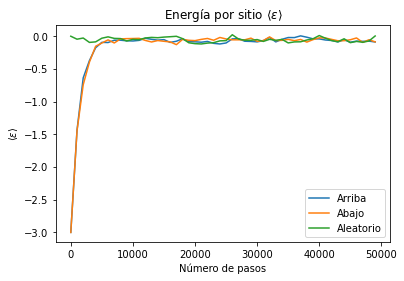

In [15]:
# plt.figure(figsize=(8,7))
plt.plot(np.arange(len(e1))*k, e1, label="Arriba")
plt.plot(np.arange(len(e2))*k, e2, label="Abajo")
plt.plot(np.arange(len(e3))*k, e3, label="Aleatorio")
# plt.ylim(bottom=-2.0, top=0.0);
plt.legend();
plt.title(r"Energía por sitio $\langle \varepsilon\rangle$");  
plt.ylabel(r"$\langle \varepsilon\rangle$"); plt.xlabel("Número de pasos")
plt.show()

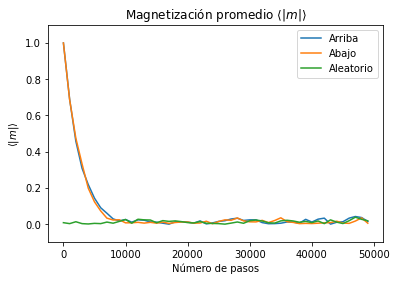

In [16]:
# plt.figure(figsize=(17,7))
plt.plot(np.arange(len(mag1))*k, np.abs(mag1), label="Arriba")
plt.plot(np.arange(len(mag2))*k, np.abs(mag2), label="Abajo")
plt.plot(np.arange(len(mag3))*k, np.abs(mag3),label="Aleatorio")
plt.ylim(bottom=-0.1, top=1.1); plt.legend();
plt.title(r"Magnetización promedio $\langle |m|\rangle$"); plt.ylabel(r"$\langle |m|\rangle$"); plt.xlabel("Número de pasos")
plt.show()

## Cálculo de observables
Energía por sitio $\langle \varepsilon \rangle$, magnetización absoluta promedio $\langle |m|\rangle$, calor específico a campo magnético constante $c_H$ y susceptibilidad magnética $\chi$

In [29]:
N = 65; g = 0
T = np.linspace(1, 10, num=30);  # Temperatura 
k = 500;                         # Cuentas para observables 
M = 50000;                       # Número de configuraciones
saltos = 1;                     # Cambios de spin
# batch_size = 16                  # de preferencia potencias de 2

vecinos = arreglo_vecinos(matriz_prueba(N), N, g)
E = []; mags = [];
C_h = []; Chi = [];

for t in np.arange(len(T)):
    config = evolucion(C_f1, N, vecinos, T[t], M, saltos=saltos)
    e, mag = observables(config, M, k)

    E.append(np.mean(e[3:]))
    mags.append(np.mean(np.abs(mag[3:])))
    C_h.append(T[t]**(-2)*np.var(e[3:]))
    Chi.append(1/T[t]*np.var(mag[3:]))

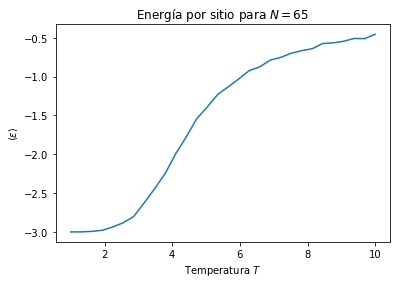

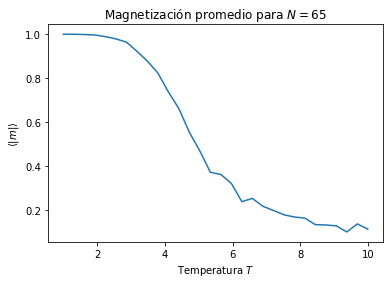

In [30]:
plt.plot(T, E); plt.title(r"$T$ vs $\langle \varepsilon\rangle$"); 
# plt.axvline(x=1050, c="r", label = r"$T_c=1050\ K$")
plt.title(r"Energía por sitio para $N=65$"); 
plt.ylabel(r"$\langle \varepsilon\rangle$"); plt.xlabel("Temperatura $T$")
# plt.legend(); 
plt.show();

# plt.figure(figsize=(17,7))
plt.plot(T, mags); plt.title(r"$T$ vs $\langle |m|\rangle$"); 
# plt.axvline(x=1050, c="r", label = r"$T_c=1050\ K$")
plt.title(r"Magnetización promedio para $N=65$"); 
plt.ylabel(r"$\langle |m|\rangle$"); plt.xlabel("Temperatura $T$")
# plt.legend(); 
plt.show();

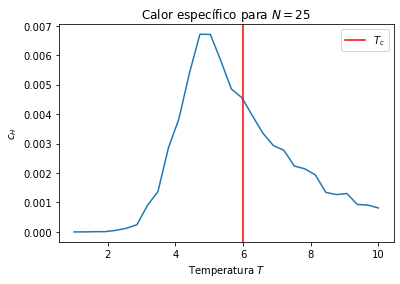

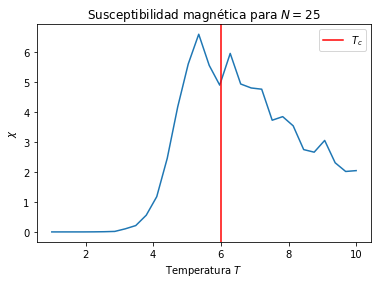

In [31]:
plt.plot(T, C_h); plt.title(r"$T$ vs $\langle \varepsilon\rangle$"); 
plt.axvline(x=6, c="r", label = r"$T_c$")
plt.title(r"Calor específico para $N=25$"); plt.ylabel(r"$c_H$"); plt.xlabel("Temperatura $T$")
plt.legend(); plt.show();
# plt.figure(figsize=(17,7))
plt.plot(T, np.array(Chi)*25**2); plt.title(r"$T$ vs $\langle |m|\rangle$"); 
plt.axvline(x=6, c="r", label = r"$T_c$")
plt.title(r"Susceptibilidad magnética para $N=25$"); plt.ylabel(r"$\chi$"); plt.xlabel("Temperatura $T$")
plt.legend(); plt.show();

### Guardar datos

In [32]:
datos = []
for i in np.arange(len(T)):
    datos.append([T[i], E[i], mags[i], C_h[i], Chi[i]])
filename = "observables_n" + str(N) + "g" + str(g) + ".txt"
df = pd.DataFrame(datos, columns = ["Temperatura", "Energía por sitio", "Magnetización absoluta",
                                    "Calor específico", "Susceptibilidad magnética"])

df.to_csv(filename, header=True, index=False, sep='\t', mode='w') # a=append, w=overwrite